# **CMSC320 Final Project**
## **Checkpoint 2**
### Group: Jerico Estrella, Tanush Parhi, Ronit Munshi, Jake Glendon, Sang Pham


In [ ]:
# import libraries
import pandas as pd
from datetime import datetime
import string

### **Data preprocessing**

#### **Dataset #1**

(a) import

In [ ]:
df1 = pd.read_csv("VideoGamesSales-2016.csv")
print(df1.shape)
print(df1.dtypes)
display(df1)

(16719, 16)
Name                   str
Platform               str
Year_of_Release    float64
Genre                  str
Publisher              str
NA_Sales           float64
EU_Sales           float64
JP_Sales           float64
Other_Sales        float64
Global_Sales       float64
Critic_Score       float64
Critic_Count       float64
User_Score             str
User_Count         float64
Developer              str
Rating                 str
dtype: object


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,Tecmo Koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16715,LMA Manager 2007,X360,2006.0,Sports,Codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16716,Haitaka no Psychedelica,PSV,2016.0,Adventure,Idea Factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16717,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN


(b) parse

In [ ]:
# makes all the string data in lowercase and makes sure any whitespace is removed
df1["Name"] = df1["Name"].str.lower().str.strip()
df1["Platform"] = df1["Platform"].str.lower().str.strip()
df1["Publisher"] = df1["Publisher"].str.lower().str.strip()
df1["Genre"] = df1["Genre"].str.lower().str.strip()
df1["Developer"] = df1["Developer"].str.lower().str.strip()
df1["Rating"] = df1["Rating"].str.lower().str.strip()

display(df1)


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,wii sports,wii,2006.0,sports,nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,nintendo,e
1,super mario bros.,nes,1985.0,platform,nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,mario kart wii,wii,2008.0,racing,nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,nintendo,e
3,wii sports resort,wii,2009.0,sports,nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,nintendo,e
4,pokemon red/pokemon blue,gb,1996.0,role-playing,nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,samurai warriors: sanada maru,ps3,2016.0,action,tecmo koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16715,lma manager 2007,x360,2006.0,sports,codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16716,haitaka no psychedelica,psv,2016.0,adventure,idea factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16717,spirits & spells,gba,2003.0,platform,wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# drops any sales that are NULL
df1 = df1.dropna(subset=["Global_Sales"])
# drops any duplucaite row entries
df1 = df1.drop_duplicates()
# only used rows where total sales greater than 0
df1 = df1[df1["Global_Sales"] > 0]

print(df1.shape)
display(df1)


(16719, 16)


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,wii sports,wii,2006.0,sports,nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,nintendo,e
1,super mario bros.,nes,1985.0,platform,nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,mario kart wii,wii,2008.0,racing,nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,nintendo,e
3,wii sports resort,wii,2009.0,sports,nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,nintendo,e
4,pokemon red/pokemon blue,gb,1996.0,role-playing,nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,samurai warriors: sanada maru,ps3,2016.0,action,tecmo koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16715,lma manager 2007,x360,2006.0,sports,codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16716,haitaka no psychedelica,psv,2016.0,adventure,idea factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16717,spirits & spells,gba,2003.0,platform,wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# converts the year column to Int64 integers from floats, with any NaNs becoming nullable ints
df1["Year_of_Release"] = pd.to_numeric(df1['Year_of_Release'], errors='coerce').astype('Int64')
# makes sure that the user score stays in its numeric float64 types
df1["User_Score"] = pd.to_numeric(df1['User_Score'], errors='coerce')

print(df1.dtypes)
display(df1)


Name                   str
Platform               str
Year_of_Release      Int64
Genre                  str
Publisher              str
NA_Sales           float64
EU_Sales           float64
JP_Sales           float64
Other_Sales        float64
Global_Sales       float64
Critic_Score       float64
Critic_Count       float64
User_Score         float64
User_Count         float64
Developer              str
Rating                 str
dtype: object


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,wii sports,wii,2006,sports,nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,nintendo,e
1,super mario bros.,nes,1985,platform,nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,mario kart wii,wii,2008,racing,nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,nintendo,e
3,wii sports resort,wii,2009,sports,nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,nintendo,e
4,pokemon red/pokemon blue,gb,1996,role-playing,nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,samurai warriors: sanada maru,ps3,2016,action,tecmo koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16715,lma manager 2007,x360,2006,sports,codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16716,haitaka no psychedelica,psv,2016,adventure,idea factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16717,spirits & spells,gba,2003,platform,wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# makes sure that the Critic_Score stays in its numeric float64 types
df1['Critic_Score'] = pd.to_numeric(df1['Critic_Score'], errors='coerce')

# Converts the critics_count and user-count columns to Int64 since they are whole numbers
# with any NaNs being converted to nullable integers
df1['Critic_Count'] = pd.to_numeric(df1['Critic_Count'], errors='coerce').astype('Int64')
df1['User_Count'] = pd.to_numeric(df1['User_Count'], errors='coerce').astype('Int64')

# makes sure the sales data is still in the form of float64 decimals
df1['JP_Sales'] = pd.to_numeric(df1['JP_Sales'], errors='coerce')
df1['NA_Sales'] = pd.to_numeric(df1['NA_Sales'], errors='coerce')
df1['EU_Sales'] = pd.to_numeric(df1['EU_Sales'], errors='coerce')
df1['Other_Sales'] = pd.to_numeric(df1['Other_Sales'], errors='coerce')
df1['Global_Sales'] = pd.to_numeric(df1['Global_Sales'], errors='coerce')

print(df1.dtypes)
display(df1)


Name                   str
Platform               str
Year_of_Release      Int64
Genre                  str
Publisher              str
NA_Sales           float64
EU_Sales           float64
JP_Sales           float64
Other_Sales        float64
Global_Sales       float64
Critic_Score       float64
Critic_Count         Int64
User_Score         float64
User_Count           Int64
Developer              str
Rating                 str
dtype: object


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,wii sports,wii,2006,sports,nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51,8.0,322,nintendo,e
1,super mario bros.,nes,1985,platform,nintendo,29.08,3.58,6.81,0.77,40.24,NaN,<NA>,NaN,<NA>,NaN,NaN
2,mario kart wii,wii,2008,racing,nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73,8.3,709,nintendo,e
3,wii sports resort,wii,2009,sports,nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73,8.0,192,nintendo,e
4,pokemon red/pokemon blue,gb,1996,role-playing,nintendo,11.27,8.89,10.22,1.00,31.37,NaN,<NA>,NaN,<NA>,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,samurai warriors: sanada maru,ps3,2016,action,tecmo koei,0.00,0.00,0.01,0.00,0.01,NaN,<NA>,NaN,<NA>,NaN,NaN
16715,lma manager 2007,x360,2006,sports,codemasters,0.00,0.01,0.00,0.00,0.01,NaN,<NA>,NaN,<NA>,NaN,NaN
16716,haitaka no psychedelica,psv,2016,adventure,idea factory,0.00,0.00,0.01,0.00,0.01,NaN,<NA>,NaN,<NA>,NaN,NaN
16717,spirits & spells,gba,2003,platform,wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,<NA>,NaN,<NA>,NaN,NaN


In [ ]:
# cheecks if anu of the sales data has any nulls by suming up the total
# nulls in each column
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

df1[sales_cols].isnull().sum()


,0
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0
Global_Sales,0


(c) organize

In [ ]:
# extracts all the common columns between this dataset and the second dataset below
df1 = df1[["Name", "Publisher", "Platform", "Genre", "Year_of_Release", "Global_Sales", "NA_Sales", "JP_Sales", "EU_Sales", "Other_Sales", "Critic_Score"]]

# makes all the column names lowercase and makes Name match the second dataset's name
renaming_scheme = {
    'Name': 'game_name',
    'Platform': 'platform',
    'Genre': 'genre',
    'Year_of_Release': 'release_year',
    'Publisher': 'publisher',
    'Developer': 'developer',
    'Critic_Score': 'critic_score',
    'Global_Sales': 'total_sales',
    'NA_Sales': 'na_sales',
    'JP_Sales': 'jp_sales',
    'EU_Sales': 'eu_sales',
    'Other_Sales': 'other_sales',
}

# renames all the columns according to the renaming scheme
df1 = df1.rename(columns=renaming_scheme)

print(df1.dtypes)
display(df1)


game_name           str
publisher           str
platform            str
genre               str
release_year      Int64
total_sales     float64
na_sales        float64
jp_sales        float64
eu_sales        float64
other_sales     float64
critic_score    float64
dtype: object


,game_name,publisher,platform,genre,release_year,total_sales,na_sales,jp_sales,eu_sales,other_sales,critic_score
0,wii sports,nintendo,wii,sports,2006,82.53,41.36,3.77,28.96,8.45,76.0
1,super mario bros.,nintendo,nes,platform,1985,40.24,29.08,6.81,3.58,0.77,NaN
2,mario kart wii,nintendo,wii,racing,2008,35.52,15.68,3.79,12.76,3.29,82.0
3,wii sports resort,nintendo,wii,sports,2009,32.77,15.61,3.28,10.93,2.95,80.0
4,pokemon red/pokemon blue,nintendo,gb,role-playing,1996,31.37,11.27,10.22,8.89,1.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16714,samurai warriors: sanada maru,tecmo koei,ps3,action,2016,0.01,0.00,0.01,0.00,0.00,NaN
16715,lma manager 2007,codemasters,x360,sports,2006,0.01,0.00,0.00,0.01,0.00,NaN
16716,haitaka no psychedelica,idea factory,psv,adventure,2016,0.01,0.00,0.01,0.00,0.00,NaN
16717,spirits & spells,wanadoo,gba,platform,2003,0.01,0.01,0.00,0.00,0.00,NaN


#### **Dataset #2**

(a) import

In [ ]:
df2 = pd.read_csv("vgchartz-2024.csv")
df2.shape

(64016, 14)

(b) parse

In [ ]:
# lowercasing
df2["title"] = df2["title"].str.lower().str.strip()
df2["console"] = df2["console"].str.lower().str.strip()
df2["publisher"] = df2["publisher"].str.lower().str.strip()
df2["genre"] = df2["genre"].str.lower().str.strip()

# Extract year in release_date column and make release year column
df2["release_date"] = pd.to_datetime(df2["release_date"])
df2["release_year"] = df2["release_date"].dt.year.astype("Int64")

# drop
df2 = df2.dropna(subset=["total_sales"]) # remove any missing/null values
df2 = df2.drop_duplicates()

# filter
df2 = df2[df2["total_sales"] > 0] # only used rows where total sales greater than 0

# replace
df2["na_sales"] = df2["na_sales"].fillna(0)
df2["jp_sales"] = df2["jp_sales"].fillna(0)
df2["pal_sales"] = df2["pal_sales"].fillna(0)
df2["other_sales"] = df2["other_sales"].fillna(0)
df2["critic_score"] = df2["critic_score"] * 10 # Replace score to 100 scale


(c) organize

In [ ]:
# Extract useful columns
df2 = df2[["title", "publisher", "console", "genre", "release_year", "total_sales", "na_sales", "jp_sales", "pal_sales", "other_sales", "critic_score"]]

# rename
df2 = df2.rename(columns={"title": "game_name"})
df2 = df2.rename(columns={"pal_sales": "eu_sales"})
df2 = df2.rename(columns={"console": "platform"})

print(df2.isna().sum())
df2

game_name           0
publisher           0
platform            0
genre               0
release_year       62
total_sales         0
na_sales            0
jp_sales            0
eu_sales            0
other_sales         0
critic_score    13592
dtype: int64


,game_name,publisher,platform,genre,release_year,total_sales,na_sales,jp_sales,eu_sales,other_sales,critic_score
0,grand theft auto v,rockstar games,ps3,action,2013,20.32,6.37,0.99,9.85,3.12,94.0
1,grand theft auto v,rockstar games,ps4,action,2014,19.39,6.06,0.60,9.71,3.02,97.0
2,grand theft auto: vice city,rockstar games,ps2,action,2002,16.15,8.41,0.47,5.49,1.78,96.0
3,grand theft auto v,rockstar games,x360,action,2013,15.86,9.06,0.06,5.33,1.42,NaN
4,call of duty: black ops 3,activision,ps4,shooter,2015,15.09,6.18,0.41,6.05,2.44,81.0
...,...,...,...,...,...,...,...,...,...,...,...
17565,root double: before crime * after days,yeti,x360,visual novel,2012,0.01,0.00,0.01,0.00,0.00,NaN
17566,gakuen hetalia,idea factory,ds,visual novel,2012,0.01,0.00,0.01,0.00,0.00,NaN
17567,chaos;child: love chu chu!!,5pb,psv,visual novel,2017,0.01,0.00,0.01,0.00,0.00,NaN
17568,doukoku soshite... doukoku soshite...,el dia,ps4,visual novel,2018,0.01,0.00,0.01,0.00,0.00,NaN


**Combining/Merging Datasets**

In [ ]:
# Ensures game_name and platform columns in both datasets are similar format and style. Removes punctuation, lowercases, whitespace.
for col in ["game_name", "platform"]:
    df1[col] = df1[col].str.lower().str.strip().str.replace(r'[^a-z0-9 ]', '', regex=True)
    df2[col] = df2[col].str.lower().str.strip().str.replace(r'[^a-z0-9 ]', '', regex=True)

# Combine
df = pd.merge(df1, df2, how="outer")

# Add
df["missing_count"] = df.isna().sum(axis=1) # keeps account on number of missing values per row

# Sort
df = df.sort_values(["game_name", "platform", "missing_count"], ascending=[True, True, True]) # Sorts by game_name then platform then missing count

# Drop/Remove
df = df.groupby(["game_name", "platform"], as_index=False).first() # groups same game_name on same platform, grabs first index which that is not a null value
df = df.drop(columns=["missing_count"])
df = df.dropna(subset=["publisher"]) # remove any missing/null values

# Checking to see missing values after merging and cleaning data
print("After Merge & Cleaning Dups:")
print(df.shape)
print(df.isna().sum())

# Bin total sales into 5 categories
df["sales_lvl"] = pd.cut(df["total_sales"],
                            bins=[0, 0.05, 0.2, 0.45, 0.9, float("inf")],
                            labels=["poor", "low", "medium", "high", "hit"]
                         )
print(df["sales_lvl"].value_counts()) # displays distribution of values per categort

# Fill
df["critic_score"] = df["critic_score"].fillna(
    df.groupby(["genre", "sales_lvl"], observed=True)["critic_score"].transform("median")
)
df = df.dropna(subset=["critic_score"]) # remove any remaining missing/null values

# Checking to see missing values after filling
print("After Filling:")
print(df.isna().sum())

df.sort_values(["critic_score"], ascending=False)


After Merge & Cleaning Dups:
(19280, 11)
game_name           0
platform            0
publisher           0
genre               0
release_year       71
total_sales         0
na_sales            0
jp_sales            0
eu_sales            0
other_sales         0
critic_score    10141
dtype: int64
sales_lvl
low       5907
poor      5360
medium    3455
hit       2415
high      2143
Name: count, dtype: int64
After Filling:
game_name        0
platform         0
publisher        0
genre            0
release_year    71
total_sales      0
na_sales         0
jp_sales         0
eu_sales         0
other_sales      0
critic_score     0
sales_lvl        0
dtype: int64


,game_name,platform,publisher,genre,release_year,total_sales,na_sales,jp_sales,eu_sales,other_sales,critic_score,sales_lvl
13001,red dead redemption undead nightmare,x360,rockstar games,action,2010,1.11,0.61,0.02,0.38,0.10,100.0,hit
13000,red dead redemption undead nightmare,ps3,rockstar games,action,2010,1.18,0.47,0.06,0.45,0.19,100.0,hit
6066,grand theft auto iv,x360,rockstar games,action,2008,11.09,6.80,0.14,3.11,1.04,100.0,hit
6065,grand theft auto iv,ps3,rockstar games,action,2008,10.57,4.79,0.44,3.73,1.62,100.0,hit
13372,rockstar games double pack grand theft auto ii...,xb,rockstar games,action,2003,2.49,1.84,0.00,0.56,0.09,98.0,hit
...,...,...,...,...,...,...,...,...,...,...,...,...
4483,elf bowling 1 2,gba,ignition entertainment,sports,2005,0.03,0.02,0.00,0.01,0.00,14.0,poor
2164,carmageddon 64,n64,titus,action,1999,0.01,0.01,0.00,0.00,0.00,13.0,poor
13180,ride to hell,ps3,deep silver,racing,2013,0.04,0.02,0.00,0.01,0.01,13.0,poor
13235,risen 3 titan lords enhanced edition,ps4,deep silver,role-playing,2015,0.07,0.00,0.00,0.06,0.01,10.0,low


### **Basic data exploration and summary statistics**

- Conclusion #1:

**2) Platform Vs Sales**

Before performing any hypothesis testing, we first examine summary statistics of total sales by platform to understand how sales are distributed across different gaming systems.

In [ ]:
df.groupby("platform")["total_sales"].describe()

,count,mean,std,min,25%,50%,75%,max
platform,,,,,,,,
2600,133.0,0.729925,0.917241,0.07,0.2900,0.460,0.7800,7.81
3do,4.0,0.047500,0.034034,0.02,0.0200,0.040,0.0675,0.09
3ds,691.0,0.419161,1.255738,0.01,0.0400,0.110,0.3000,14.60
dc,53.0,0.303962,0.465937,0.02,0.0800,0.140,0.2900,2.42
ds,2281.0,0.357887,1.387781,0.01,0.0400,0.100,0.2600,29.80
gb,102.0,2.520098,5.275899,0.06,0.3000,1.120,2.0875,31.37
gba,851.0,0.375288,0.883715,0.01,0.0500,0.150,0.3750,15.85
gbc,3.0,1.446667,0.768462,0.56,1.2100,1.860,1.8900,1.92
gc,569.0,0.354060,0.678751,0.01,0.0700,0.150,0.3500,7.07


We use Levene’s test to evaluate whether the variance in total sales is similar across different platforms.

In [ ]:
from scipy.stats import levene

# split data into platform groups
groups = [g["total_sales"].values for _, g in df.groupby("platform")]

# run Levene’s test for equal variances across platforms
stat, p = levene(*groups)


print(stat, p)

12.235899962251962 1.0801577776088078e-75


ANOVA is used to test whether the average total sales differ across platforms. This helps determine if platform has a significant effect on game sales.

In [ ]:
from scipy.stats import f_oneway

groups = []

# loop through each platform group
for name, group in df.groupby("platform"):
    # keep only platforms with enough data points for reliable testing
    if len(group) >= 5:
        groups.append(group["total_sales"].values)

# perform one-way ANOVA across platform groups
f_stat, p_val = f_oneway(*groups)

# strength of differences between group means
print("F-statistic:", f_stat)

# significance of those differences
print("p-value:", p_val)

F-statistic: 25.22842607484863
p-value: 1.3310069364243527e-132


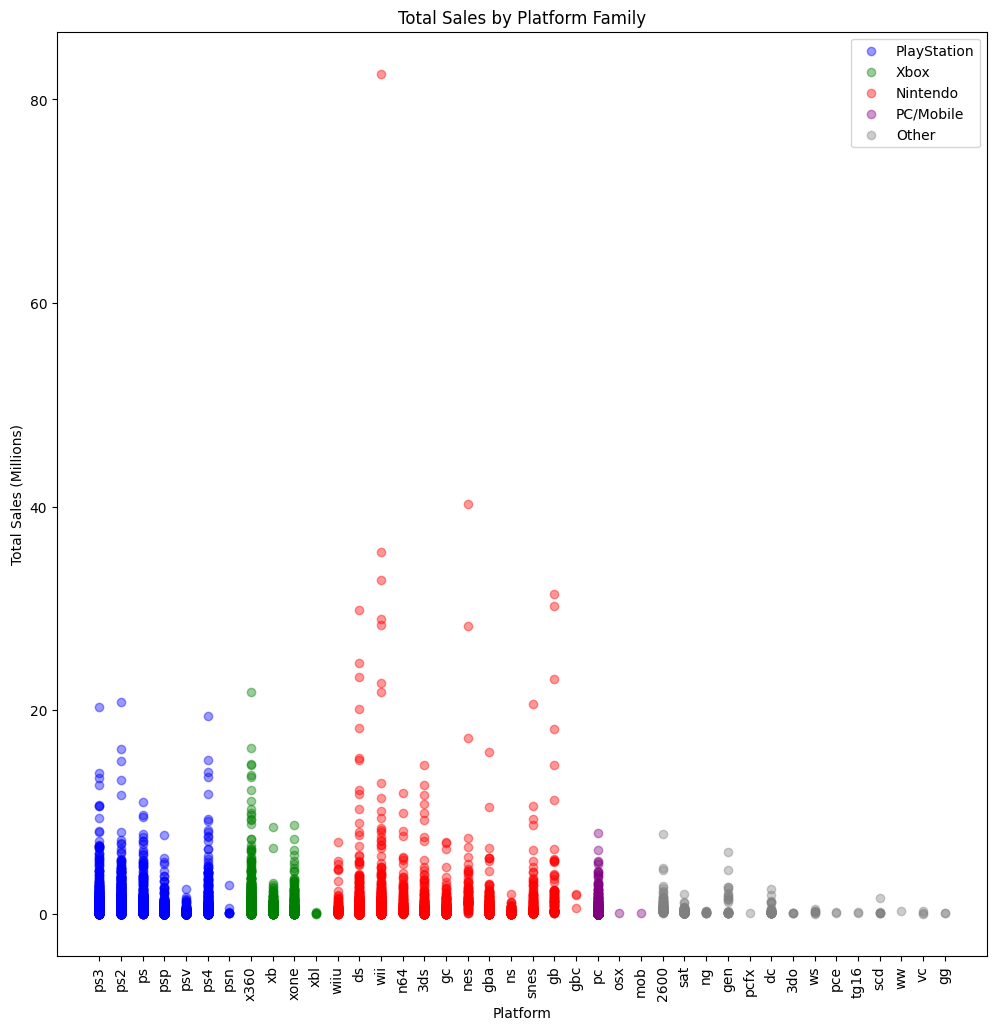

In [ ]:
import matplotlib.pyplot as plt

# function that groups each platform into a broader console family category
def get_family(platform):
    ps = ["ps", "ps2", "ps3", "ps4", "psp", "psv", "psn"]
    xbox = ["xb", "x360", "xone", "xbl"]
    nintendo = ["nes", "snes", "n64", "gc", "wii", "wiiu", "ds", "3ds", "gb", "gba", "gbc", "ns"]
    pc = ["pc", "osx", "linux", "mob"]

    if platform in ps:
        return "PlayStation"
    elif platform in xbox:
        return "Xbox"
    elif platform in nintendo:
        return "Nintendo"
    elif platform in pc:
        return "PC/Mobile"
    else:
        return "Other"

# dictionary mapping each platform family to a plot color
family_colors = {
    "PlayStation": "blue",
    "Xbox": "green",
    "Nintendo": "red",
    "PC/Mobile": "purple",
    "Other": "gray"
}

# create a new column that assigns each platform to its family category
df["family"] = df["platform"].apply(get_family)

# recreate color mapping for plotting (redundant but used for visualization)
family_colors = {
    "PlayStation": "blue",
    "Xbox": "green",
    "Nintendo": "red",
    "PC/Mobile": "purple",
    "Other": "gray"
}

plt.figure(figsize=(12,12))

for family, color in family_colors.items():
    subset = df[df["family"] == family]
    plt.scatter(subset["platform"], subset["total_sales"],
                label=family, alpha=0.4, color=color)

plt.xticks(rotation=90)
plt.xlabel("Platform")
plt.ylabel("Total Sales (Millions)")
plt.title("Total Sales by Platform Family")
plt.legend()
plt.show()

**CONCLUSION**

**Descriptive Statistics & Dataset Characteristics** :
We begin by exploring the main characteristics of the dataset using descriptive statistics. The data shows a strong right-skew in total game sales across platforms, where most games have relatively low sales while a small number of titles account for extremely high values. This suggests that sales are not evenly distributed and are heavily influenced by a few blockbuster games.

**Outliers and Distribution**: One of the most notable outliers is Wii Sports on the Wii platform, which sold approximately 82.53 million units. This value is significantly higher than most other games in the dataset and has a strong effect on the overall distribution. Because of this, the dataset contains high variability within certain platforms, especially those with major hit titles.

**Feature Relationships :** There also appears to be some relationship between categorical features such as platform and the total sales of a game. Certain platforms tend to have higher-performing titles on average, suggesting that platform choice may influence sales outcomes.

**Assumptions and Choice of Analysis Methods:** To compare sales across platforms, we use statistical hypothesis testing methods. We check assumptions such as equal variance using Levene’s test. ANOVA is then used to test whether there are significant differences in mean sales between platforms. The results indicate that the variance in sales is not equal across platforms. This suggest that platform does have a statistically significant effect on sales. However, because the data is heavily skewed, contains extreme outliers, and violates equal variance assumptions, the results should be interpreted with caution.

- Conclusion #3:

Spearman correlation: -0.2008, P-value: 8.3364e-169
Linear Regression slope: -0.02475, R: -0.2050, P-value: 5.8747e-176
Mann-Whitney U: 47630234, P-value: 2.4076e-94
Early era median: 0.19M  |  Late era median: 0.12M


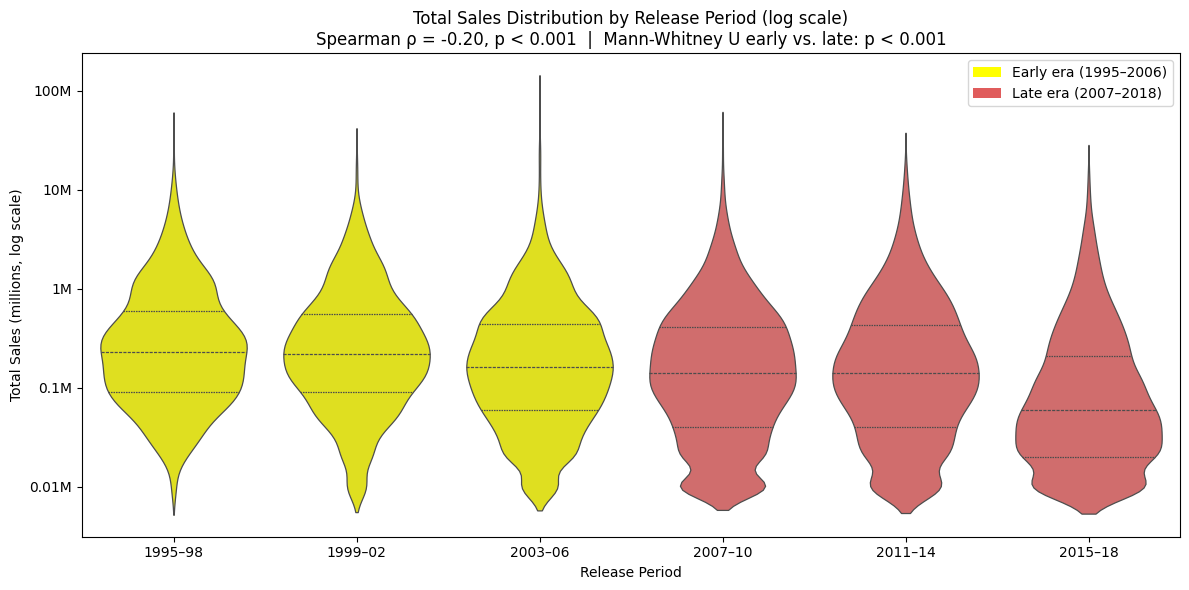

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import spearmanr, mannwhitneyu, linregress
from matplotlib.patches import Patch

# filter to years
df_year = df[(df["release_year"] >= 1995) & (df["release_year"] <= 2018)].copy()
df_year["release_year"] = df_year["release_year"].astype(int)
df_year["log_sales"] = np.log10(df_year["total_sales"])

# group into 4-year bins so violin shapes are readable
bins   = [1994, 1998, 2002, 2006, 2010, 2014, 2018]
labels = ["1995–98", "1999–02", "2003–06", "2007–10", "2011–14", "2015–18"]
df_year["period"] = pd.cut(df_year["release_year"], bins=bins, labels=labels)

# Spearman Rank Correlation: tests for a monotonic relationship between release year and total sales.
spearman_r = df_year[["release_year", "total_sales"]].corr(method="spearman").loc[
    "release_year", "total_sales"
]
_, spearman_pvalue = spearmanr(df_year["release_year"], df_year["total_sales"])
print(f"Spearman correlation: {spearman_r:.4f}, P-value: {spearman_pvalue:.4e}")

# Linear Regression: Log-transform stabilizes the skewed distribution
# t-test
slope, intercept, r_value, p_value, std_err = linregress(
    df_year["release_year"], df_year["log_sales"]
)
print(f"Linear Regression slope: {slope:.5f}, R: {r_value:.4f}, P-value: {p_value:.4e}")

# Mann-Whitney: two-group test comparing early vs. late era sales
early = df_year[df_year["release_year"] <= 2006]["total_sales"]
late  = df_year[df_year["release_year"] >  2006]["total_sales"]
mw_statistic, mw_pvalue = mannwhitneyu(early, late, alternative="greater")
print(f"Mann-Whitney U: {mw_statistic:.0f}, P-value: {mw_pvalue:.4e}")
print(f"Early era median: {early.median():.2f}M  |  Late era median: {late.median():.2f}M")

# violin plot
df_year["era"] = df_year["release_year"].apply(
    lambda y: "Early (1995–2006)" if y <= 2006 else "Late (2007–2018)"
)

plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df_year,
    x="period",
    y="log_sales",
    hue="era",
    palette={"Early (1995–2006)": "yellow", "Late (2007–2018)": "#E05C5C"},
    dodge=False,
    density_norm="width",
    inner="quart",
    linewidth=0.9,
    legend=False,
)

plt.axvline(x=2.5, color="white", linewidth=1.2, linestyle="--", alpha=0.5)

plt.title(
    "Total Sales Distribution by Release Period (log scale)\n"
    f"Spearman ρ = {spearman_r:.2f}, p < 0.001  |  Mann-Whitney U early vs. late: p < 0.001"
)
plt.xlabel("Release Period")
plt.ylabel("Total Sales (millions, log scale)")
plt.yticks(
    ticks=[-2, -1, 0, 1, 2],
    labels=["0.01M", "0.1M", "1M", "10M", "100M"]
)

legend_elements = [Patch(facecolor="yellow", label="Early era (1995–2006)"),
                   Patch(facecolor="#E05C5C", label="Late era (2007–2018)")]
plt.legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
plt.show()

**H₀: Release year has no effect on a game's total global sales. Games from different release eras sell the same amount on average.**

**H₁: Release year does have an effect on total global sales. Games from earlier release eras sell more than games from later release eras.**

**Conclusion:**

All three tests point to the same answer: **newer games do not sell better and actually sell less per title, which is statistically significant.**
The Spearman correlation (ρ = 0.20, p < 0.001) shows a significant negative monotonic relationship between release year and total sales. Spearman was chosen over Pearson because total sales are heavily right skewed, where a small number of blockbuster titles inflate the mean, so rank based correlation is more reliable. The linear regression on log transformed sales confirms this: the slope of 0.025 log units per year means each additional year is associated with about a 5.6% lower sales per title on average (p < 0.001). The Mann Whitney U test (p < 0.001) then directly compares the two eras without any normality assumptions, showing that early era games from 1995 to 2006 with a median of 0.19M outsell late era games from 2007 to 2018 with a median of 0.12M.

The violin plot makes the pattern clear. The early era violins are wider and sit higher, with more mass above the 0.1M mark, while the late era violins compress and shift downward toward lower sales. The most likely explanation for this is market saturation. The number of games released per year grew from around 216 in 1995 to over 1,500 by 2008 and 2009, which split consumer spending across far more titles at once. This means more competition with roughly the same market size, so each individual game ended up with a smaller share.

This also has implications for the rest of the analysis. Release year should be treated as a control variable in any model built later on, since it can confound both genre and platform comparisons. Older platforms and genres might appear to perform better simply because they faced less competition at the time, not because of anything specifically correlating to the genre or platform itself.